In [2]:
from astropy.table import Table
from astropy.io import fits

import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import kcorrect.kcorrect

## data

In [3]:
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/'
NSA_FN = DATA_FOLDER + 'nsa_v1_0_1.fits'

In [4]:
NSA = Table.read(NSA_FN)
NSA[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6833158000.0,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0
J094630.85-004554.5,09h/m00/J094630.85-004554.5,146.6285851269414,-0.7651620976591762,1,-1,-1,-1,-1,-1,17.318521,0.06465632,sdss,0.06491773,1239,2,175,301,735.56384,1277.3636,1,0.06403577,2.4606192 .. 443.66675,5.447516 .. 0.006137319,1,2.6590455 .. 454.05856,-14.978118 .. -20.68

In [32]:
c = 3*10**5
H0 = 100

## test galaxy

In [5]:
idx=123
NSA[idx]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64
J094224.27-000004.9,09h/m00/J094224.27-000004.9,145.6011390709911,-0.0013671905114679848,131,-1,-1,-1,-1,-1,17.504244,0.14582263,sdss,0.022198617,1239,4,169,301,49.811268,101.75503,131,0.14521615,0.805167 .. 333.5299,7.724879 .. 0.010399645,1,0.30995274 .. 343.45767,-16.88012 .. -22.296806,4.248297 .. 981.38495,0.5244154 .. 0.09355975,1.200844 .. 0.07440743,1.1417835e-05 .. 2.9086522e-29,0.00064971414 .. 0.8982847,2.2497255e-10,0.24177825,0.030908003,48829180000.0,99.72005462646484,99.6318130493164,7 .. 10,0.07669225 .. 0.0,822.69037 .. 0.0,0.021337591 .. 0.22268315,0.0048810896 .. 0.27901575,0.9571602 .. 0.47385678,6.44251 .. 25.703274,2.1107605 .. 259.2156,7.685113 .. 0.019449737,0.22410917 .. 79.49266,197.69098 .. 0.92861784,0.60340637,114.140564,0.4715793,114.59256,0.49672934 .. 317.47598,20.435537 .. 0.098309696,1.6527082,0.34595644,114.82071,-0.014962465 .. -0.0011629909,0.1510942 .. 0.101522,0 .. 0,0,3,v2_1_13,0.22341923 .. 258.39,5.7860413,2.8180869,7.7302065,4.2433486,266,223,51630,145.60116327726791,-0.0013816899468873237,0.0,sdss,legacy,good,122,145.6012,-0.001388682,0.4715793,114.59256,147.8705,0.97714794,7.9890795,3.663227,9.593311,7.9890795,2.1484284 .. 241.73032,6.4406343 .. 0.025219286,4.6943064 .. 3.0555928,8.471206 .. 8.44094,0.9653436,1.1281146 .. 0.9358473,1.1136963 .. 0.93381083,3.4824674 .. 253.95398,2.3562255 .. 0.010752433,1,3.3930972 .. 257.56528,-17.360464 .. -21.920372,24.240538 .. 588.25836,0.09118549 .. -0.006078572,8.0220424e-08 .. 1.2368397e-11,29033390000.0,9.8062555e-05 .. 0.76703036,4.4291755e-05,0.090715155,0.021834781,1.0


### K-correction applied to ELPETRO_NMGY (ugriz)
supposedly nmgy is already corrected for galactic extinction

In [7]:
responses = ['sdss_u0', 'sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0']
kc = kcorrect.kcorrect.Kcorrect(responses=responses)

In [59]:
redshift = NSA[idx]['Z']
maggies = NSA['ELPETRO_NMGY'][idx][2:]*10**-9
ivar = NSA['ELPETRO_NMGY_IVAR'][idx][2:]*10**18

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar,
                      )

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs, 
                   # reconstruct=True, band_shift=0.1
                  )

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

Text(0, 0.5, 'ELPETRO_ABSMAG')

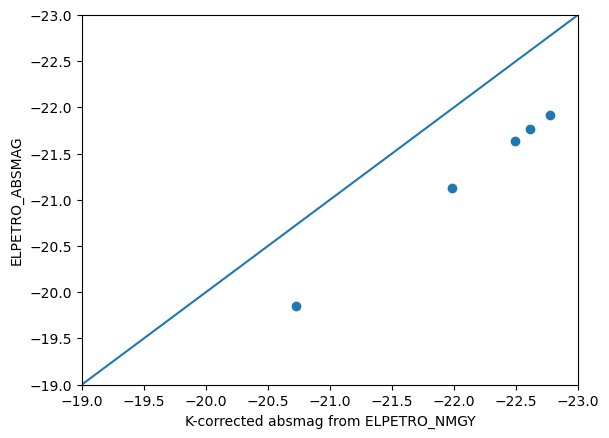

In [61]:
# compare with NSA ELPETRO_ABSMAG

plt.scatter(absmag, NSA['ELPETRO_ABSMAG'][idx][2:])
plt.plot([-19,-23],[-19,-23])
plt.xlim(-19,-23)
plt.ylim(-19,-23)

plt.xlabel('K-corrected absmag from ELPETRO_NMGY')
plt.ylabel('ELPETRO_ABSMAG')

Text(0, 0.5, 'ELPETRO_KCOEFF')

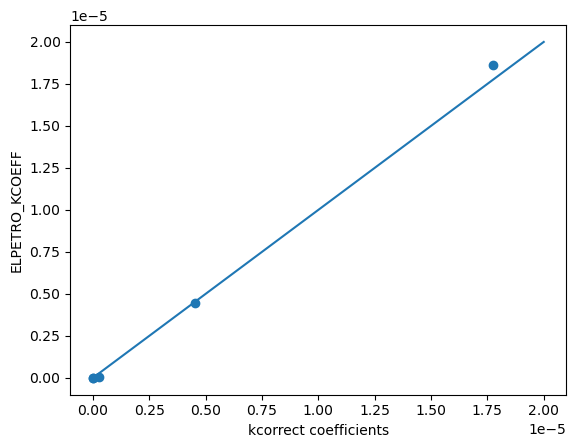

In [62]:
# compare k-coefficients

plt.scatter(coeffs, NSA['ELPETRO_KCOEFF'][idx])
plt.plot([0,2*10**-5],[0,2*10**-5])

plt.xlabel('kcorrect coefficients')
plt.ylabel('ELPETRO_KCOEFF')


Text(0, 0.5, 'ELPETRO_KCORRECT')

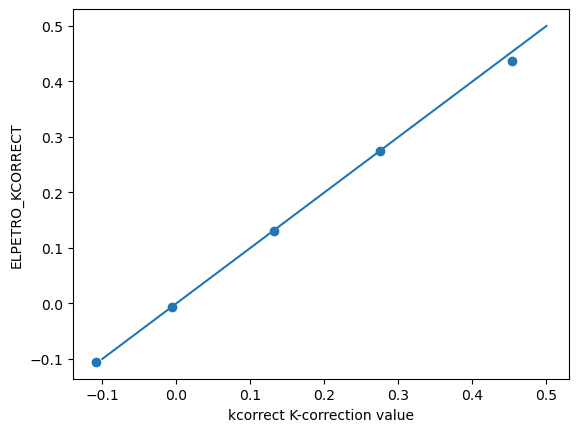

In [63]:
# compare K-correction value

plt.scatter(k, NSA['ELPETRO_KCORRECT'][idx][2:])
plt.plot([-0.1,0.5],[-0.1,0.5])

plt.xlabel('kcorrect K-correction value')
plt.ylabel('ELPETRO_KCORRECT')


#### test the conversion to mag manually
convert nmgy to AB magnitude and apply k-correction

In [64]:
def nmgy_to_AB(flux):

    return 22.5 - 2.5*np.log10(flux)

def app_to_abs_mag(mag, z):

    d = c*z/H0 *10**6

    return mag - 5*np.log10(d)+5

In [65]:
elpetro_nmgy_AB = nmgy_to_AB(maggies*10**9) # apparent magnitude
elpetro_nmgy_AB_abs = app_to_abs_mag(elpetro_nmgy_AB, redshift)
elpetro_nmgy_AB_abs

masked_array(data=[-19.207237861271693, -20.642078266434684,
                   -21.29345970448917, -21.656940732629195,
                   -21.71661841659811],
             mask=[False, False, False, False, False],
       fill_value=nan)

In [66]:
absmag

array([-20.725954, -21.983196, -22.491188, -22.613243, -22.77596 ],
      dtype=float32)

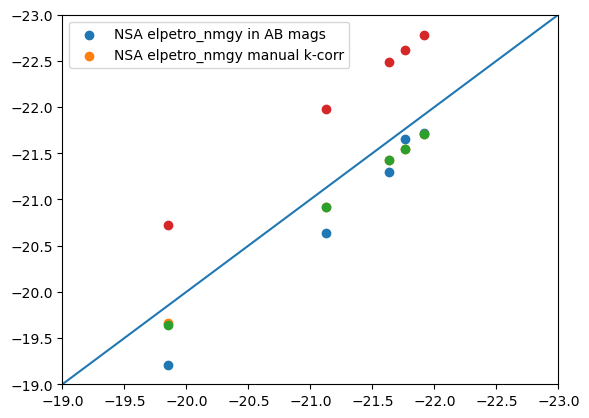

In [68]:
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], elpetro_nmgy_AB_abs, label='NSA elpetro_nmgy in AB mags')
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], elpetro_nmgy_AB_abs - k, label='NSA elpetro_nmgy manual k-corr')
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], elpetro_nmgy_AB_abs - NSA['ELPETRO_KCORRECT'][idx][2:])
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], absmag)
plt.xlim(-19,-23)
plt.ylim(-19,-23)
plt.plot([-19,-23],[-19,-23])
plt.legend()

### K-correction (ELPETRO_KCOEFF) applied to ELPETRO_NMGY

In [51]:
absmag_2 = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=NSA['ELPETRO_KCOEFF'][idx], 
                   # reconstruct=True
                  )

Text(0, 0.5, 'ELPETRO_ABSMAG')

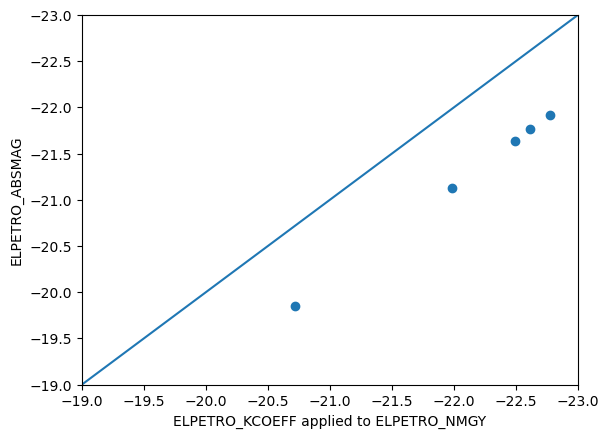

In [53]:
plt.scatter(absmag_2, NSA['ELPETRO_ABSMAG'][idx][2:])
plt.plot([-19,-23],[-19,-23])
plt.xlim(-19,-23)
plt.ylim(-19,-23)

plt.xlabel('ELPETRO_KCOEFF applied to ELPETRO_NMGY')
plt.ylabel('ELPETRO_ABSMAG')

### K-correction applied to ELPETRO_FLUX (ugriz)

In [36]:
maggies_flux = NSA['ELPETRO_FLUX'][idx][2:]*10**-9
ivar_flux = NSA['ELPETRO_FLUX_IVAR'][idx][2:]*10**18

coeffs_flux = kc.fit_coeffs(redshift=redshift, maggies=maggies_flux, ivar=ivar_flux)

absmag_flux = kc.absmag(redshift=redshift, maggies=maggies_flux, ivar=ivar_flux, coeffs=coeffs_flux, 
                   # reconstruct=True
                  )

k_flux = kc.kcorrect(redshift=redshift, coeffs=coeffs_flux)

Text(0, 0.5, 'ELPETRO_ABSMAG')

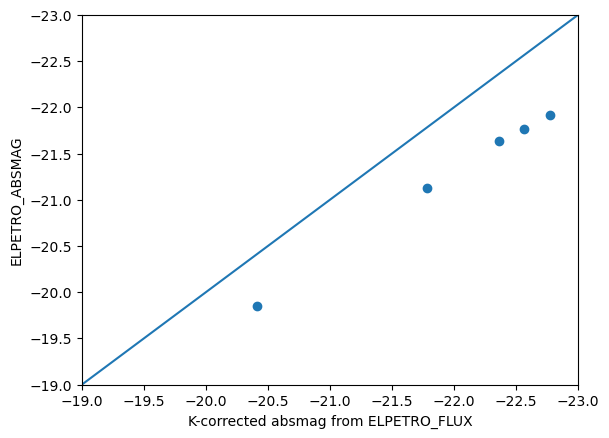

In [37]:
# compare with NSA ELPETRO_ABSMAG

plt.scatter(absmag_flux, NSA['ELPETRO_ABSMAG'][idx][2:])
plt.plot([-19,-23],[-19,-23])
plt.xlim(-19,-23)
plt.ylim(-19,-23)

plt.xlabel('K-corrected absmag from ELPETRO_FLUX')
plt.ylabel('ELPETRO_ABSMAG')

### try on rnmgy

In [43]:
maggies_rnmgy = NSA['ELPETRO_RNMGY'][idx][2:]*10**-9
ivar_rnmgy = NSA['ELPETRO_NMGY_IVAR'][idx][2:]*10**18

coeffs_rnmgy = kc.fit_coeffs(redshift=redshift, maggies=maggies_rnmgy, ivar=ivar_rnmgy)

absmag_rnmgy = kc.absmag(redshift=redshift, maggies=maggies_rnmgy, ivar=ivar_rnmgy, coeffs=coeffs_rnmgy, 
                   # reconstruct=True, 
                         band_shift=0.1
                  )

k_rnmgy = kc.kcorrect(redshift=redshift, coeffs=coeffs_rnmgy)

Text(0, 0.5, 'ELPETRO_ABSMAG')

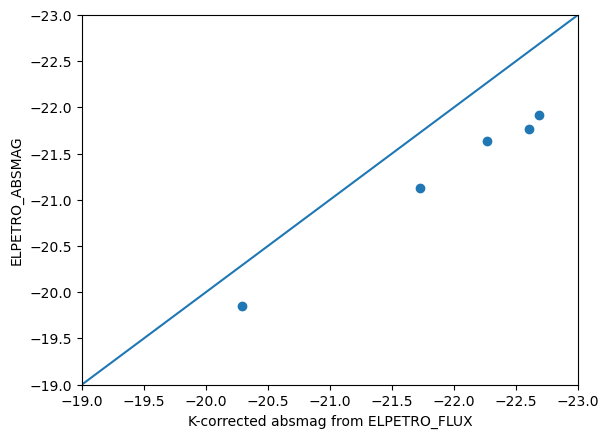

In [44]:
# compare with NSA ELPETRO_ABSMAG

plt.scatter(absmag_rnmgy, NSA['ELPETRO_ABSMAG'][idx][2:])
plt.plot([-19,-23],[-19,-23])
plt.xlim(-19,-23)
plt.ylim(-19,-23)

plt.xlabel('K-corrected absmag from ELPETRO_FLUX')
plt.ylabel('ELPETRO_ABSMAG')

In [39]:
elpetro_rnmgy_AB = nmgy_to_AB(maggies*10**9) # apparent magnitude
elpetro_rnmgy_AB_abs = app_to_abs_mag(elpetro_nmgy_AB, redshift)
elpetro_rnmgy_AB_abs

masked_array(data=[-19.207237861271693, -20.642078266434684,
                   -21.29345970448917, -21.656940732629195,
                   -21.71661841659811],
             mask=[False, False, False, False, False],
       fill_value=nan)

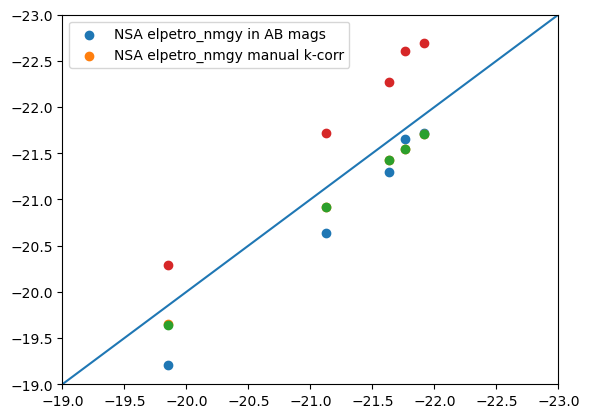

In [50]:
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], elpetro_rnmgy_AB_abs, label='NSA elpetro_nmgy in AB mags')
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], elpetro_rnmgy_AB_abs - k_rnmgy, label='NSA elpetro_nmgy manual k-corr')
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], elpetro_rnmgy_AB_abs - NSA['ELPETRO_KCORRECT'][idx][2:])
plt.scatter(NSA['ELPETRO_ABSMAG'][idx][2:], absmag_rnmgy)
plt.xlim(-19,-23)
plt.ylim(-19,-23)
plt.plot([-19,-23],[-19,-23])
plt.legend()